# Basics of word2vec


## Download the model
Download <code>google-news-vectors</code> model. Open it using the <code>gensim</code> library.

In [1]:
! pip install -q -U gensim
! pip install -q opendatasets
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/leadbest/googlenewsvectorsnegative300")

# To quickly load data, enter your login and token from Kaggle
# or remove the last line, upload the file locally to colab (slow)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.2 MB/s eta 0:00:00
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: xtereo
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/leadbest/googlenewsvectorsnegative300


100%|██████████| 3.17G/3.17G [00:41<00:00, 82.6MB/s]


In [4]:
import warnings
warnings.filterwarnings('ignore')

import gensim
from gensim.models import KeyedVectors

w = KeyedVectors.load_word2vec_format("googlenewsvectorsnegative300/GoogleNews-vectors-negative300.bin",
                                      binary=True)

The structure is entitled <code>KeyedVectors</code> and in essence it is an embedding between the keys and the vectors. Each vector is identified by its search key, this is most often a short string token,  therefore, it's normally a correspondance between

<center><code>{str => 1D numpy array}</code></center><br/>



For example, let's dispaly first 10 coordinates of a vector, corresponding to the word <code>sunrise</code>

In [5]:
print(gensim.__version__)
print("Vector size: ", w["sunrise"].shape)
print("The first 10 coordinates of a vector: \n", w["sunrise"][:10])

4.4.0
Vector size:  (300,)
The first 10 coordinates of a vector: 
 [-0.22558594 -0.03540039 -0.21679688  0.03613281 -0.2265625  -0.09814453
  0.109375   -0.34570312  0.18652344  0.01806641]


## Task 1. Similarity.

Build vectors for the words <code>London</code>, <code>England</code>, <code>Moscow</code>. Compute the cosine distance between the words <code>London</code> and <code>England</code> and between the words <code>Moscow</code> and <code>England</code>. In which pair the words are more similar to each other? Hint: to compute cosine distance use the <code>distance()</code> method. The correct answer is presented in the outputs.
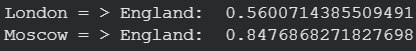

In [68]:
#enter your code here
from gensim.matutils import cossim

def cos_dist(a, b):
  return 1 - (a @ b)/(np.linalg.norm(a)*np.linalg.norm(b))
london_w = w["London"]
england_w = w["England"]
moscow_w = w["Moscow"]
print("London = > England", cos_dist(london_w, england_w))
print("Moscow => England", cos_dist(moscow_w, england_w))
print(cos_dist(w["vodka"], w["drink"]))

London = > England 0.56007147
Moscow => England 0.8476868
0.42848557


## Task 2. Analogies.
Using the most_similar method solve the analogy
```London : England = Moscow : X```

The correct answer is in the outputs.

(Hint: use the following arguments: positive and negative)
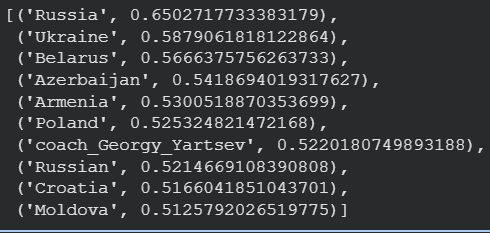

In [7]:
#enter your code here
w.most_similar(positive=['England', 'Moscow'], negative=['London'], topn=10)

[('Russia', 0.6502718329429626),
 ('Ukraine', 0.5879061818122864),
 ('Belarus', 0.5666376352310181),
 ('Azerbaijan', 0.5418694615364075),
 ('Armenia', 0.5300518870353699),
 ('Poland', 0.5253247618675232),
 ('coach_Georgy_Yartsev', 0.5220180749893188),
 ('Russian', 0.5214669108390808),
 ('Croatia', 0.5166040658950806),
 ('Moldova', 0.5125792026519775)]

## Taks 3. Similarity: find the odd-one-out word.
Using the <code>doesnt_match</code> method, find the odd-one-out word in the string <code>breakfast cereal dinner lunch</code>.

The correct answer is in the outputs.

In [43]:
#enter your code here
w.doesnt_match(["breakfast", "cereal", "dinner", "lunch"])
w.doesnt_match("vodka drink car gem".split(" "))

'gem'

## Task 4. Sentence vector representation


A sentence is given: <code>the quick brown fox jumps over the lazy dog</code>. You need to represent this sentence as a vector. Therefore, build the vector representation for each word in the model, and then average the vectors component-wise.


In [46]:
import numpy as np

#enter your code here
def sent2vec(sentence):
  words = sentence.split(" ")
  vectors = [w[word] for word in words]
  return np.mean(vectors, axis=0)
print(cos_dist(sent2vec("empty vessel makes much noise"), sent2vec("idle brain is the devil workshop")))

0.57229626


# Two models comparison

## Download one more model


Let's read the google-news-vectors model and the model, trained on British national corpus http://vectors.nlpl.eu/repository/20/0.zip, using gensim.


In [11]:
! wget -c http://vectors.nlpl.eu/repository/20/0.zip
! unzip 0.zip
! head -3 model.txt

--2026-03-06 16:55:24--  http://vectors.nlpl.eu/repository/20/0.zip
Resolving vectors.nlpl.eu (vectors.nlpl.eu)... 129.240.189.200, 2001:700:112::200
Connecting to vectors.nlpl.eu (vectors.nlpl.eu)|129.240.189.200|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344050746 (328M) [application/zip]
Saving to: ‘0.zip’

0.zip               100%[===================>] 328.11M  19.6MB/s    in 18s     

2026-03-06 16:55:43 (18.6 MB/s) - ‘0.zip’ saved [344050746/344050746]

Archive:  0.zip
  inflating: meta.json               
  inflating: model.bin               
  inflating: model.txt               
  inflating: README                  
163473 300
say_VERB -0.008861 0.097097 0.100236 0.070044 -0.079279 0.000923 -0.012829 0.064301 -0.029405 -0.009858 -0.017753 0.063115 0.033623 0.019805 0.052704 -0.100458 0.089387 -0.040792 -0.088936 0.110212 -0.044749 0.077675 -0.017062 -0.063745 -0.009502 -0.079371 0.066952 -0.070209 0.063761 -0.038194 -0.046252 0.049983 -0.094985 -0.

Let's download the model, trained on the British national corpus

In [12]:
w_british = KeyedVectors.load_word2vec_format("model.bin", binary=True)

Note, that the vector size also equals 300 in this case. Specify the part of speech of the word of interest by means of underscore . All words should be lowercased.

In [13]:
try:
    print(w_british["London_NOUN"].shape)
    print('upper is ok')
except:
    print(w_british["london_NOUN"].shape)
    print('lower is ok')

(300,)
lower is ok


In [47]:
print(cos_dist(w_british["vodka_NOUN"], w_british["drink_NOUN"]))
print(w_british.doesnt_match("vodka_NOUN drink_VERB car_NOUN gem_NOUN".split(" ")))

0.41066295
gem_NOUN


## The dataset for the quality evaluation
Let's download the wordsim353 dataset.



In [18]:
! tar -xvf ws353simrel.tar
! head -5 wordsim353_sim_rel/wordsim_similarity_goldstandard.txt

wordsim353_sim_rel/wordsim353_agreed.txt
wordsim353_sim_rel/wordsim353_annotator1.txt
wordsim353_sim_rel/wordsim353_annotator2.txt
wordsim353_sim_rel/wordsim_relatedness_goldstandard.txt
wordsim353_sim_rel/wordsim_similarity_goldstandard.txt
tiger	cat	7.35
tiger	tiger	10.00
plane	car	5.77
train	car	6.31
television	radio	6.77


## Testing dataset preparation


Let's extract word pairs from the file `wordsim_similarity_goldstandard.txt` and compute the vector cosine similarity in each model. Compute the correlation between the similarity estimators of the google-news-vectors model model and human ratings of the wordsim dataset, and then - the similarity correlation between the model based on British national corpus and a human ratings of the wordsim dataset. Which model is closer to the human ratings?

(use only such words from wordsim dataset, which have the corresponding vectors in the British national corpus labeled as NOUNs!)

In [19]:
import pandas as pd

df = pd.read_csv("wordsim353_sim_rel/wordsim_similarity_goldstandard.txt",
                 sep="\t", header=None)
df.columns = ["first", "second", "score"]
df.head(3)

,first,second,score
0,tiger,cat,7.35
1,tiger,tiger,10.00
2,plane,car,5.77


## Model similarity evaluation
We use only such words from wordsim dataset, which have the corresponding vectors in the British national corpus labeled as nouns, make 3 sets with similarity measures:

1. Measures (cosine between vectors), obtained for the google-news-vectors model

2. Measures (cosine between vectors), obtained for the model based on the British national corpus

3. Human ratings from word_sim for the words, having the corresponding vectors in the British national corpus

The skipped words from word_sim are presented in the outputs.

In [74]:
from itertools import product
gn_dist, br_dist, scores = [], [], []

for row in df.loc[28:128, :].iterrows():


  w1, w2 = row[1]["first"], row[1]["second"]
  try:

    #enter your code here
    if (not f"{w1}_NOUN" in w_british) or (not f"{w2}_NOUN" in w_british):
      continue
    if (not w1 in w) or (not w2 in w):
      continue
    gn = max([w.distance(i1, i2) for i1, i2 in [(w1, w2), (w2, w1)]])
    gn_dist.append(gn)
    br = max([w_british.distance(i1, i2) for i1, i2 in [(f"{w1}_NOUN", f"{w2}_NOUN"), (f"{w2}_NOUN", f"{w1}_NOUN")]])
    br_dist.append(br)
    scores.append(row[1]["score"])

  except KeyError as e:
    print(e, "Skipping this word.")
print(len(gn_dist), len(br_dist), len(scores))

98 98 98


## Model selection: correlation with human ratings

Compute Spearman's correlation between each model and human ratings from word_sim.

The results are in the outputs.

In [76]:
from scipy.stats import spearmanr

#enter your code here
print(spearmanr(gn_dist, scores))
print(spearmanr(br_dist, scores))

SignificanceResult(statistic=np.float64(-0.7145075199347518), pvalue=np.float64(1.4412855763141124e-16))
SignificanceResult(statistic=np.float64(-0.6774169932123363), pvalue=np.float64(1.867662449798197e-14))


You can notice, that the google-news-vectors model is slighly better in this case.